In [1]:
# LEER EL DOCUMENTO
# Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil

from sklearn.preprocessing import MinMaxScaler

# Cargar archivo
path = '/content/train.csv'
data = pd.read_csv(path)
data

,time,pv_production,wind_production,consumption,spot_market_price,precip_1h:mm,precip_type:idx,prob_precip_1h:p,clear_sky_rad:W,clear_sky_energy_1h:J,...,t_50m:C,relative_humidity_50m:p,dew_point_50m:C,wind_speed_50m:ms,wind_dir_50m:d,t_100m:C,relative_humidity_100m:p,dew_point_100m:C,wind_speed_100m:ms,wind_dir_100m:d
0,2020-01-01 13:00:00,0.0,40.59,26.514689,0.28969,0.0,0.0,1.0,10.0,64826.0,...,8.4,60.7,1.3,8.4,246.3,8.3,60.3,1.0,10.4,247.3
1,2020-01-01 14:00:00,0.0,67.86,28.326960,0.29561,0.0,0.0,1.0,0.0,8961.1,...,8.4,61.6,1.5,8.0,252.3,8.4,60.7,1.2,10.0,252.1
2,2020-01-01 15:00:00,0.0,116.68,23.682207,0.30044,0.0,0.0,1.0,0.0,0.0,...,8.5,60.3,1.3,9.6,254.1,8.4,59.6,1.0,11.7,253.8
3,2020-01-01 16:00:00,0.0,120.22,25.354782,0.29975,0.0,0.0,1.0,0.0,0.0,...,8.4,63.9,2.0,12.1,254.6,8.3,63.4,1.7,14.3,254.2
4,2020-01-01 17:00:00,0.0,109.86,23.861942,0.29650,0.0,0.0,1.0,0.0,0.0,...,7.2,78.9,3.8,11.7,249.5,7.1,77.9,3.5,13.9,249.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9510,2021-01-31 19:00:00,0.0,21.98,44.422658,0.60243,0.0,0.0,1.0,0.0,0.0,...,-3.2,93.1,-4.2,4.8,231.2,-3.1,91.6,-4.3,6.0,238.3
9511,2021-01-31 20:00:00,0.0,9.60,45.167707,0.53335,0.0,0.0,1.0,0.0,0.0,...,-3.5,94.1,-4.3,4.9,224.9,-3.3,92.1,-4.4,6.2,231.8
9512,2021-01-31 21:00:00,0.0,22.61,32.476198,0.51195,0.0,0.0,1.0,0.0,0.0,...,-3.6,93.0,-4.6,4.7,224.5,-3.3,90.6,-4.6,6.0,231.7
9513,2021-01-31 22:00:00,0.0,21.70,28.561791,0.47122,0.0,0.0,1.0,0.0,0.0,...,-3.7,92.1,-4.8,4.5,222.8,-3.4,89.5,-4.9,5.8,231.1


In [2]:
# OUTLIERS
df_aux = data.copy()
print("Máximos:")
print(df_aux.max())

print("\nMínimos:")
print(df_aux.min())

Máximos:
time                        2021-01-31 23:00:00
pv_production                         79.855834
wind_production                           225.5
consumption                           70.366622
spot_market_price                       1.14059
precip_1h:mm                               6.22
precip_type:idx                             3.0
prob_precip_1h:p                           95.0
clear_sky_rad:W                           834.8
clear_sky_energy_1h:J                 3004661.0
diffuse_rad:W                             320.2
diffuse_rad_1h:Wh                       314.359
direct_rad:W                              683.1
direct_rad_1h:Wh                        679.067
global_rad:W                              769.6
global_rad_1h:Wh                        765.325
sunshine_duration_1h:min                   60.0
sun_azimuth:d                           359.998
sun_elevation:d                          49.879
low_cloud_cover:p                         100.0
medium_cloud_cover:p           

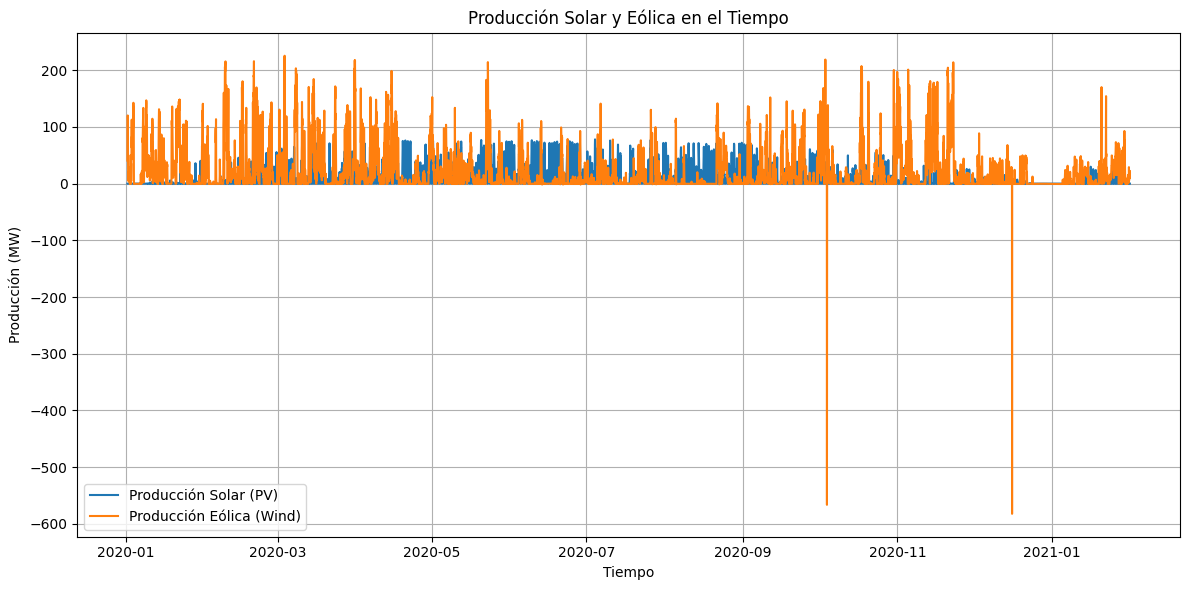

In [3]:
# GRAFICA DATOS DE VARIABLES DE GENERACION
# Columna 'time' a datetime
df_aux['time'] = pd.to_datetime(df_aux['time'])

# Establecer 'time' como índice (opcional pero recomendado para series de tiempo)
df_aux.set_index('time', inplace=True)

# Graficar
plt.figure(figsize=(12, 6))
plt.plot(df_aux['pv_production'], label='Producción Solar (PV)')
plt.plot(df_aux['wind_production'], label='Producción Eólica (Wind)')
plt.xlabel('Tiempo')
plt.ylabel('Producción (MW)')
plt.title('Producción Solar y Eólica en el Tiempo')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

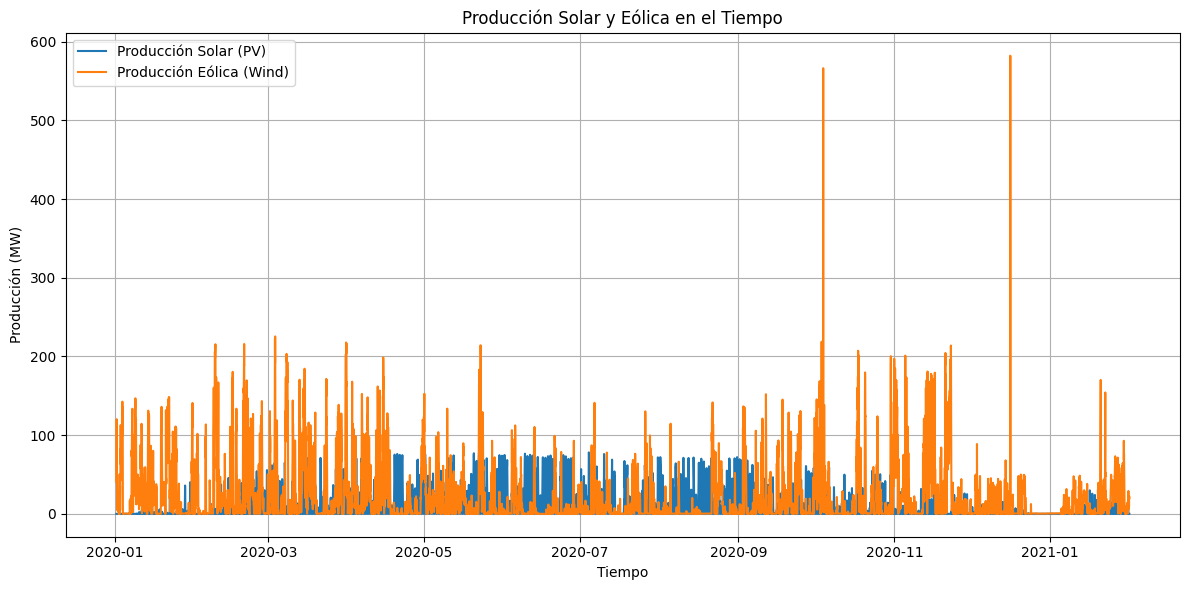

In [4]:
# ELIMINAR VALORES NEGATIVOS DE PRODUCCION
# Transformar datos a valor absoluto
df_aux['wind_production'] = df_aux['wind_production'].abs()
valores_negativos = df_aux.loc[df_aux['wind_production'] < 0, 'wind_production']

# Graficar
plt.figure(figsize=(12, 6))
plt.plot(df_aux['pv_production'], label='Producción Solar (PV)')
plt.plot(df_aux['wind_production'], label='Producción Eólica (Wind)')
plt.xlabel('Tiempo')
plt.ylabel('Producción (MW)')
plt.title('Producción Solar y Eólica en el Tiempo')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [5]:
# Elimina las 11 primerras columnas para que el dataset empiece en a las 00h00m00s
df_aux_2 = df_aux.iloc[11:]
df_aux_2 = df_aux_2.reset_index()
# Añadir la columna de hora en el dataframe
df_aux_2["hora"] = df_aux_2["time"].dt.hour
df_aux_3 = df_aux_2.drop(df_aux_2.columns[0], axis=1)  # elimina la primera columna del date time
# Escalar datos
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df_aux_3)      # df_aux_2 contiene solo columnas numéricas
df_scaled = pd.DataFrame(df_scaled, columns=df_aux_3.columns)  # Convertir de nuevo a DataFrame
# Separar el dataset en matrices de cada dia
chunks = [df_scaled.iloc[i:i+24, :] for i in range(0, len(df_scaled), 24)]

In [6]:
# Funcion guarda dfs en capetas
def guardar_dfs(nombre_carpeta, inicio, final):
    # Crear la carpeta si no existe
    os.makedirs(nombre_carpeta, exist_ok=True)

    # Guardar solo los chunks en el rango [inicio, final] (inclusive)
    for idx, chunk in enumerate(chunks[inicio:final], start=inicio):
        filename = f"{nombre_carpeta}/df_{idx}.csv"
        chunk.to_csv(filename, index=False)

In [7]:
# Crear carpetas
guardar_dfs("enero_2020", 0, 30)
guardar_dfs("febrero_2020", 30, 59)
guardar_dfs("marzo_2020", 59, 90)
guardar_dfs("abril_2020", 90, 120)
guardar_dfs("mayo_2020", 120, 151)
guardar_dfs("junio_2020", 151, 181)
guardar_dfs("julio_2020", 181, 212)
guardar_dfs("agosto_2020", 212, 243)
guardar_dfs("septiembre_2020", 243, 273)
guardar_dfs("octubre_2020", 273, 304)
guardar_dfs("noviembre_2020", 304, 334)
guardar_dfs("diciembre_2020", 334, 365)
guardar_dfs("enero_2021", 365, 396)
guardar_dfs("unificado", 0, 396)

In [8]:
# CREAR ETIQUETAS
# Rangos (inicio, fin, grupo)
rangos = [
    (0, 30, 1),
    (30, 59, 2),
    (59, 90, 3),
    (90, 120, 4),
    (120, 151, 5),
    (151, 181, 6),
    (181, 212, 7),
    (212, 243, 8),
    (243, 273, 9),
    (273, 304, 10),
    (304, 334, 11),
    (334, 365, 12),
    (365, 396, 13)
]

# Crear lista de filas
rows = []
for inicio, fin, grupo in rangos:
    for i in range(inicio, fin):
        rows.append((f"df_{i}.csv", grupo))

# Convertir a DataFrame
df_labels = pd.DataFrame(rows, columns=["filename", "grupo"])

# Guardar en CSV
df_labels.to_csv("df_grupos.csv", index=False)

In [9]:
# Crear carpeta "Categorias"
os.makedirs("Categorias", exist_ok=True)

# Mover a "Categorias" las carpetas creadas
shutil.move("abril_2020", "Categorias/")
shutil.move("agosto_2020", "Categorias/")
shutil.move("diciembre_2020", "Categorias/")
shutil.move("enero_2020", "Categorias/")
shutil.move("enero_2021", "Categorias/")
shutil.move("febrero_2020", "Categorias/")
shutil.move("julio_2020", "Categorias/")
shutil.move("junio_2020", "Categorias/")
shutil.move("marzo_2020", "Categorias/")
shutil.move("mayo_2020", "Categorias/")
shutil.move("noviembre_2020", "Categorias/")
shutil.move("octubre_2020", "Categorias/")
shutil.move("septiembre_2020", "Categorias/")
shutil.move("unificado", "Categorias/")
shutil.move("df_grupos.csv", "Categorias/")

# Exportar a CSV y mover a carpeta zip
df_aux_3.to_csv("dataframe_sin_escalar.csv", index=False)
df_scaled.to_csv("dataframe_escalado.csv", index=False)
shutil.move("dataframe_sin_escalar.csv", "Categorias/")
shutil.move("dataframe_escalado.csv", "Categorias/")


# Comprimir la carpeta "Categorias" en formato zip
shutil.make_archive("Categorias", 'zip', "Categorias")

'/content/Categorias.zip'

In [10]:
#import shutil

# Eliminar carpeta "Categorias" si existe
#shutil.rmtree("Categorias", ignore_errors=True)